##📘 Project Title
Statistical Distribution Diagnostics & Feature Transformation on Credit Card Transactions

##📌 Introduction

- In real-world machine learning systems, raw data rarely follows a perfect normal distribution. Financial transaction datasets, especially credit card transactions, often contain skewed distributions, extreme outliers, and heavy-tailed behavior. These issues can negatively affect statistical analysis and machine learning model performance.

- This project focuses on analyzing the statistical properties of credit card transaction data using distribution analysis and feature transformation techniques. The project explores concepts such as skewness, kurtosis, excess kurtosis, Q-Q plots, and different probability distributions including Uniform, Log-Normal, and Pareto distributions.

- Additionally, multiple mathematical transformation techniques such as Log Transformation, Reciprocal Transformation, Square Root Transformation, Box-Cox Transformation, and Yeo-Johnson Transformation are applied to improve data normality and reduce skewness.

- The main objective of this project is to understand how feature transformations help stabilize variance, reduce outlier influence, and make data more suitable for machine learning models and statistical analysis.

##📌 Problem Statement

Credit card transaction datasets are highly imbalanced and contain non-normal distributions with significant skewness and outliers. Such characteristics can reduce the effectiveness of machine learning algorithms and statistical methods.

The goal of this project is to:

* analyze transaction data distributions,
* interpret kurtosis and skewness,
* study Q-Q plots,
* compare theoretical distributions,
* apply feature transformation techniques,
* and evaluate how transformations improve data normality.

##📌 Objectives

- Perform statistical distribution analysis on transaction data
- Understand skewness and kurtosis
- Interpret Q-Q plots
- Study Uniform, Log-Normal, and Pareto distributions
- Apply mathematical feature transformations
- Compare transformations using skewness and kurtosis
- Improve distribution normality for ML preprocessing

##📌 Dataset Information

**Dataset Name**:

***Credit Card Fraud Detection Dataset***

##📌Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from scipy.stats import boxcox
from scipy import stats

from sklearn.preprocessing import (
    FunctionTransformer,
    PowerTransformer
)

##📌Dataset Loading

In [6]:
df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


##📌 Basic Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93181 entries, 0 to 93180
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    93181 non-null  int64  
 1   V1      93181 non-null  float64
 2   V2      93181 non-null  float64
 3   V3      93181 non-null  float64
 4   V4      93181 non-null  float64
 5   V5      93181 non-null  float64
 6   V6      93181 non-null  float64
 7   V7      93181 non-null  float64
 8   V8      93181 non-null  float64
 9   V9      93181 non-null  float64
 10  V10     93181 non-null  float64
 11  V11     93181 non-null  float64
 12  V12     93181 non-null  float64
 13  V13     93180 non-null  float64
 14  V14     93180 non-null  float64
 15  V15     93180 non-null  float64
 16  V16     93180 non-null  float64
 17  V17     93180 non-null  float64
 18  V18     93180 non-null  float64
 19  V19     93180 non-null  float64
 20  V20     93180 non-null  float64
 21  V21     93180 non-null  float64
 22

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,...,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000
mean,40720.460405,-0.263002,-0.040780,0.676306,0.163064,-0.280078,0.093917,-0.108816,0.055540,-0.036898,...,-0.029999,-0.107373,-0.037835,0.009540,0.132163,0.026936,0.001515,0.002321,99.030945,0.002286
std,16392.444505,1.869011,1.664308,1.341575,1.355105,1.368687,1.303615,1.225238,1.209672,1.123318,...,0.723135,0.634840,0.640783,0.594557,0.442183,0.495719,0.389447,0.324150,268.350415,0.047757
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,32678.000000,-1.028016,-0.605706,0.179018,-0.716783,-0.898708,-0.647692,-0.600859,-0.139122,-0.695859,...,-0.224205,-0.528068,-0.177280,-0.322364,-0.132298,-0.325627,-0.062925,-0.005614,7.600000,0.000000
50%,42848.000000,-0.258489,0.072818,0.756532,0.189117,-0.314928,-0.156536,-0.069893,0.072409,-0.109294,...,-0.057606,-0.082454,-0.049500,0.064890,0.170764,-0.070610,0.009579,0.023267,26.945000,0.000000
75%,53622.000000,1.153021,0.728656,1.381324,1.034477,0.250915,0.487658,0.415870,0.357253,0.576494,...,0.119664,0.309217,0.081457,0.406029,0.420096,0.304235,0.082701,0.076475,89.990000,0.000000
max,64283.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,18.946734,4.014444,5.541598,3.517346,12.152401,33.847808,19656.530000,1.000000


##📌 Checking Missing Values

In [9]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


##📌 Distribution Analysis

**Histogram**

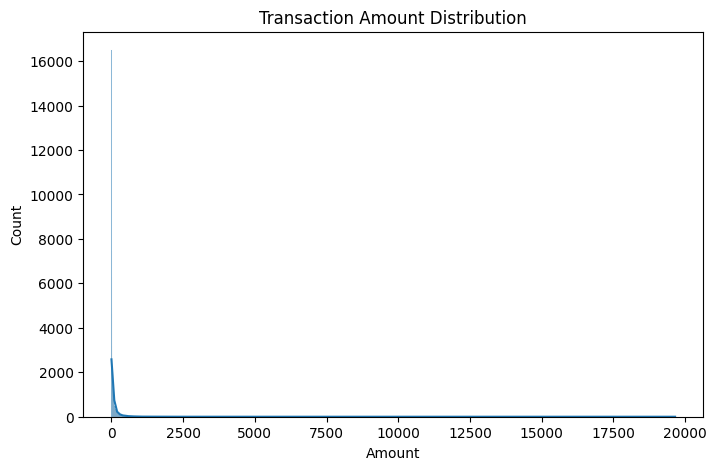

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], kde=True)

plt.title("Transaction Amount Distribution")
plt.show()

##📌 Boxplot

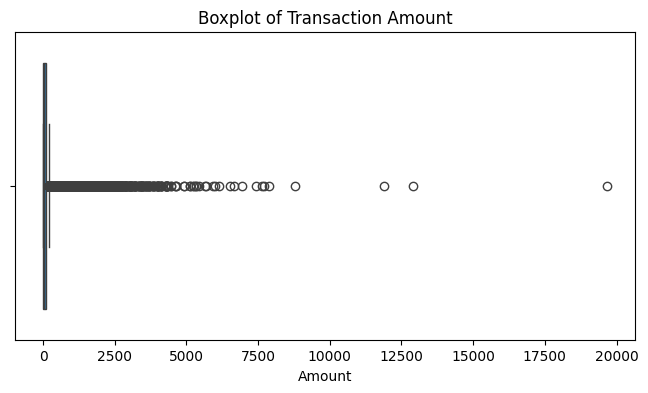

In [11]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")
plt.show()

##📌 Skewness

In [12]:
print("Skewness:", skew(df["Amount"]))

Skewness: nan


**Interpretation**
- **Positive skewness indicates right-skewed distribution.**
- **Large transaction values create a long right tail.**

##📌 Kurtosis

**Kurtosis is a statistical measure that describes the heaviness of the tails and the presence of outliers in a distribution.**

* High kurtosis indicates:

- heavy tails
- more extreme values
- higher presence of outliers

* Low kurtosis indicates:

- lighter tails

In [13]:
print("Kurtosis:", kurtosis(df["Amount"]))

Kurtosis: nan


##📌 Excess Kurtosis

**Excess kurtosis compares a distribution’s kurtosis with the normal distribution.**

- Excess Kurtosis = 0 → Normal distribution
- Excess Kurtosis > 0 → Heavy tails (Leptokurtic)
- Excess Kurtosis < 0 → Flat tails (Platykurtic)

--> ***Excess Kurtosis=Kurtosis−3***

* Types of Kurtosis:

**Mesokurtic**

* Normal distribution

**Leptokurtic**
--> Heavy tails and more outliers

**Platykurtic**
-->Flat distribution with fewer outliers

##📌 Q-Q Plot (Quantile-Quantile Plot)

**A Q-Q Plot is a graphical technique used to compare the distribution of sample data with a theoretical distribution, usually the normal distribution.**

**It helps determine whether the data follows a normal distribution.**

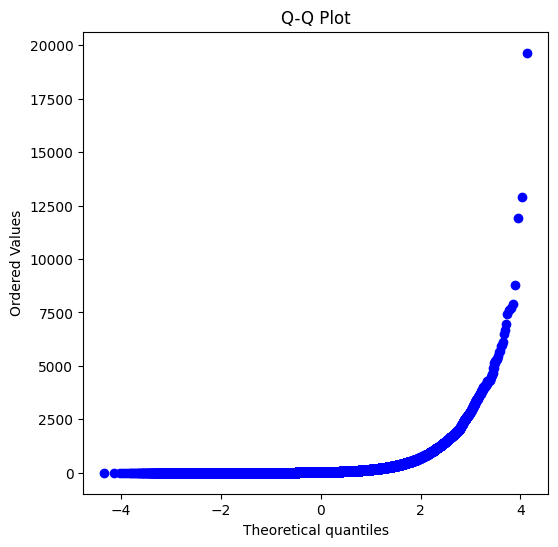

In [37]:
plt.figure(figsize=(6,6))

stats.probplot(df["Amount"], dist="norm", plot=plt)

plt.title("Q-Q Plot")

plt.savefig("qqplot.png")
plt.show()

##📌 Interpretation of Q-Q Plot

- Straight line → Normally distributed data

- Curved upward → Right skewness

- Large deviations at ends → Presence of outliers

- Heavy tail deviations → High kurtosis

##📌 Uniform Distribution

**A Uniform Distribution is a probability distribution in which all outcomes have equal probability of occurring.**

* Example:

- rolling a fair dice
- random number generation**

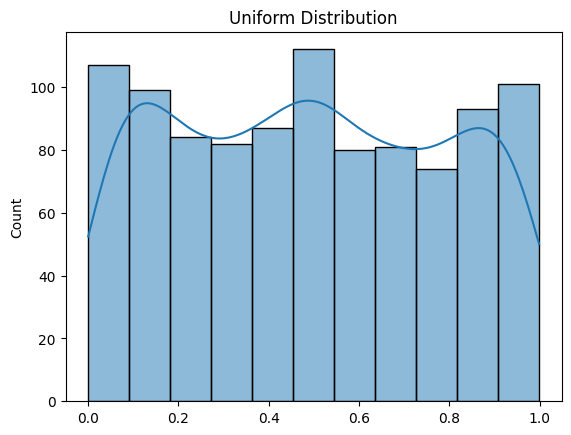

In [15]:
uniform_data = np.random.uniform(0, 1, 1000)

sns.histplot(uniform_data, kde=True)

plt.title("Uniform Distribution")
plt.show()

##📌 Log-Normal Distribution

**A variable follows a log-normal distribution if its logarithm is normally distributed.**

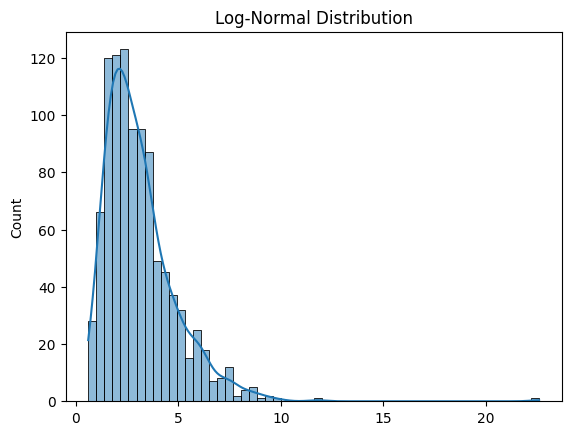

In [16]:
lognormal_data = np.random.lognormal(mean=1, sigma=0.5, size=1000)

sns.histplot(lognormal_data, kde=True)

plt.title("Log-Normal Distribution")
plt.show()

**Real-World Use Cases**

- income distribution
- transaction amounts
- stock prices

##📌 Pareto Distribution

**A Pareto Distribution is a power-law probability distribution that represents situations where a small percentage contributes to most outcomes.**

**Represents the 80/20 rule where a small percentage contributes to most outcomes.**

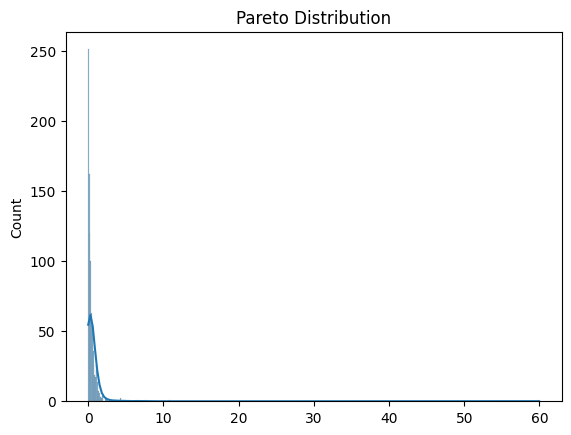

In [17]:
pareto_data = np.random.pareto(a=3, size=1000)

sns.histplot(pareto_data, kde=True)

plt.title("Pareto Distribution")
plt.show()

##📌 Mathematical Transformations

**Feature transformations help:**

- reduce skewness
- stabilize variance
- improve normality
- reduce outlier effects

##📌 Log Transformation

**Log Transformation reduces positive skewness by compressing large values.**

In [19]:
df["Log_Amount"] = np.log1p(df["Amount"])

df["Log_Amount"]

,Log_Amount
0,5.014760
1,1.305626
2,5.939276
3,4.824306
4,4.262539
...,...
93176,1.091923
93177,3.414114
93178,3.433987
93179,3.430756


##📌 Reciprocal Transformation

**Reciprocal Transformation reduces the impact of large values and extreme outliers.**

In [21]:
df["Reciprocal_Amount"] = 1 / (df["Amount"] + 1)

df["Reciprocal_Amount"]

,Reciprocal_Amount
0,0.006639
1,0.271003
2,0.002634
3,0.008032
4,0.014086
...,...
93176,0.335570
93177,0.032906
93178,0.032258
93179,0.032362


##📌 Square Root Transformation

**Square Root Transformation reduces moderate skewness and stabilizes variance.**

In [22]:
df["Sqrt_Amount"] = np.sqrt(df["Amount"])

df["Sqrt_Amount"]

,Sqrt_Amount
0,12.231925
1,1.640122
2,19.459188
3,11.113055
4,8.366003
...,...
93176,1.407125
93177,5.421254
93178,5.477226
93179,5.468089


##📌 Function Transformer

**Function Transformer is a Scikit-learn utility used to apply custom mathematical transformations to features.**

**It allows reusable preprocessing within machine learning pipelines.**

In [23]:
transformer = FunctionTransformer(np.log1p)

df["Function_Transform"] = transformer.transform(df[["Amount"]])

df["Function_Transform"]

,Function_Transform
0,5.014760
1,1.305626
2,5.939276
3,4.824306
4,4.262539
...,...
93176,1.091923
93177,3.414114
93178,3.433987
93179,3.430756


##📌 Power Transformer

**Power Transformer is a preprocessing technique used to make data more Gaussian-like and stabilize variance.**

In [24]:
pt = PowerTransformer(method="yeo-johnson")

df["Power_Transform"] = pt.fit_transform(df[["Amount"]])

df["Power_Transform"]

,Power_Transform
0,1.036236
1,-1.205344
2,1.567061
3,0.925536
4,0.596301
...,...
93176,-1.340149
93177,0.091287
93178,0.103225
93179,0.101284


##📌 Box-Cox Transformation

**Works only on positive values**

In [31]:
amount_data = df["Amount"]

# Remove missing/infinite values
amount_data = amount_data.replace([np.inf, -np.inf], np.nan)
amount_data = amount_data.dropna()

# Add 1 to avoid zero values
boxcox_data, lam = boxcox(amount_data + 1)

print("Lambda:", lam)

Lambda: -0.021995626065070297


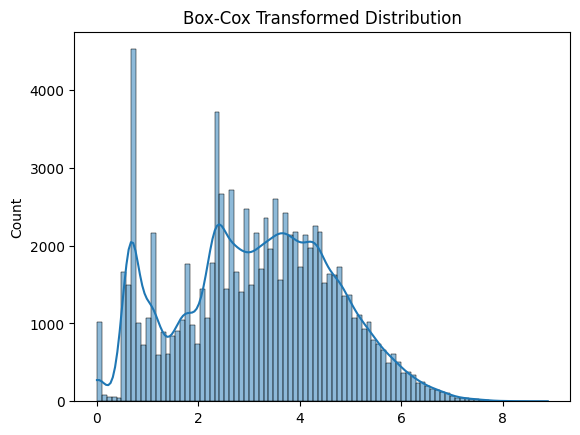

In [33]:
sns.histplot(boxcox_data, kde=True)

plt.title("Box-Cox Transformed Distribution")
plt.show()

In [34]:
print("Original Skewness:", skew(amount_data))
print("Box-Cox Skewness:", skew(boxcox_data))

Original Skewness: 14.215915639911277
Box-Cox Skewness: 0.007907466977909791


##📌 Interpretation of Box-Cox Transformation
- Box-Cox Transformation was applied to reduce skewness and stabilize variance in the transaction amount feature.

- The original distribution was highly right-skewed with extreme outliers.

- After applying Box-Cox Transformation, the distribution became more symmetric and closer to a normal distribution.

* This transformation helps improve:


- statistical analysis

- model assumptions

- machine learning performance

- variance stability


**Since Box-Cox works only on positive values, 1 was added to the transaction amount before transformation.**




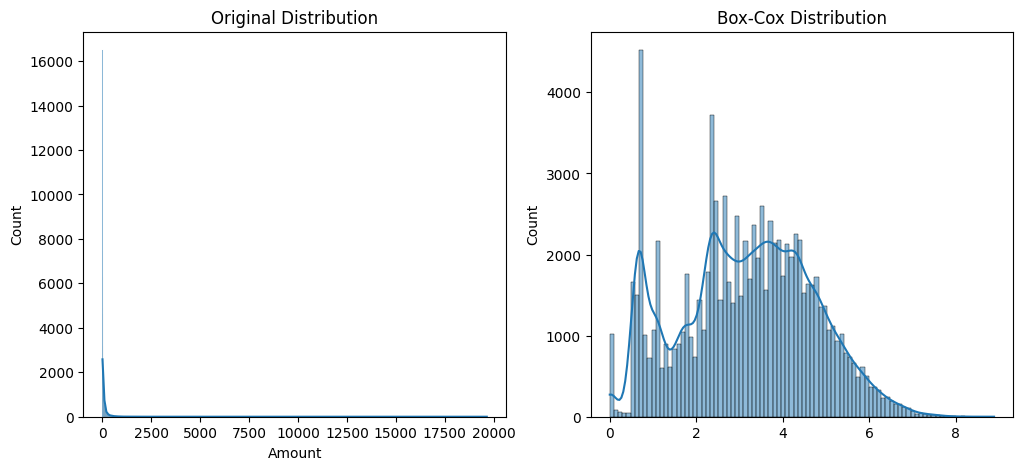

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(amount_data, kde=True, ax=ax[0])
ax[0].set_title("Original Distribution")

sns.histplot(boxcox_data, kde=True, ax=ax[1])
ax[1].set_title("Box-Cox Distribution")

plt.savefig("boxcox.png")
plt.show()

***The Box-Cox transformation significantly reduced skewness and improved distribution normality, making the feature more suitable for statistical modeling and machine learning preprocessing.***

##📌 Yeo-Johnson Transformation
**Handles:**
- zero values
- negative values

In [26]:
pt_yj = PowerTransformer(method="yeo-johnson")

df["Yeo_Johnson"] = pt_yj.fit_transform(df[["Amount"]])

##📌 Before vs After Transformation Comparison

In [27]:
transformations = {
    "Original": df["Amount"],
    "Log": df["Log_Amount"],
    "Sqrt": df["Sqrt_Amount"],
    "Yeo-Johnson": df["Yeo_Johnson"]
}

for name, data in transformations.items():
    print(name)
    print("Skewness:", skew(data))
    print("Kurtosis:", kurtosis(data))
    print()

Original
Skewness: nan
Kurtosis: nan

Log
Skewness: nan
Kurtosis: nan

Sqrt
Skewness: nan
Kurtosis: nan

Yeo-Johnson
Skewness: nan
Kurtosis: nan



##📌 Conclusion

- **This project analyzed the statistical properties of credit card transaction data using distribution diagnostics and feature transformation techniques.**

- **The original transaction amount feature showed strong positive skewness and high kurtosis, indicating the presence of heavy tails and extreme outliers. Q-Q plot analysis further confirmed that the data did not follow a normal distribution.**

- **Different mathematical transformations such as Log, Reciprocal, Square Root, Box-Cox, and Yeo-Johnson transformations were applied to improve data normality and reduce skewness. Among these, Power Transformations such as Box-Cox and Yeo-Johnson provided significant improvements in stabilizing variance and reducing skewness.**

- **Overall, this project demonstrates the importance of statistical preprocessing and feature transformation in preparing real-world financial data for machine learning and advanced analytics.**